<a href="https://www.kaggle.com/code/evelinj/notebook2ff3e70e46?scriptVersionId=347679736" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# My Contribution: Fine-Tuned Hybrid ResNet50–VGG16 for Liver Fibrosis Staging
### Simple version — trains the improved model, evaluates it, and saves it

**The contribution in one line:** the base paper (Adesina et al., *iLIVER* 2026) keeps
ResNet50/VGG16 fully **frozen** the whole time. This notebook adds a second **fine-tuning stage**
that unfreezes the last block of each backbone and continues training at a low learning rate —
so the pretrained ImageNet filters get adapted to ultrasound texture instead of staying generic.

This notebook is intentionally short: one model, one training run (two stages), one evaluation,
one saved model file — ready to quote numbers from in a conference paper.

**Setup on Kaggle (no dataset download needed):**
1. "+ Add Input" → search "liver fibrosis ultrasound" → attach the dataset.
2. Settings → Accelerator: GPU. Settings → Internet: On (needed once for ImageNet weights).
3. Run All.


## 1. Setup

In [1]:

import os, glob, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5
CLASS_NAMES = ['F0', 'F1', 'F2', 'F3', 'F4']

print('TensorFlow:', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Load the dataset (auto-discovers it under /kaggle/input — no download needed)

In [2]:

SEARCH_ROOT = '/kaggle/input'
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def find_class_dirs(root, class_names=CLASS_NAMES):
    found = {c: [] for c in class_names}
    for dirpath, _, _ in os.walk(root):
        base = os.path.basename(dirpath)
        for c in class_names:
            if base.upper() == c:
                found[c].append(dirpath)
    return found

class_dirs = find_class_dirs(SEARCH_ROOT)

records = []
for label_idx, c in enumerate(CLASS_NAMES):
    for d in class_dirs[c]:
        for f in glob.glob(os.path.join(d, '**', '*'), recursive=True):
            if f.lower().endswith(IMG_EXTS):
                records.append({'filepath': f, 'label': label_idx, 'stage': c})

df = pd.DataFrame(records).drop_duplicates(subset='filepath').reset_index(drop=True)
assert len(df) > 0, "No images found — check dataset folder names under /kaggle/input."
print('Total images:', len(df))
print(df['stage'].value_counts().reindex(CLASS_NAMES))


Total images: 6323
stage
F0    2114
F1     861
F2     793
F3     857
F4    1698
Name: count, dtype: int64


## 3. Train/test split (80:20) and class weights

In [3]:

train_df, test_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=SEED)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print('Train:', len(train_df), '| Test:', len(test_df))

N, K = len(train_df), NUM_CLASSES
class_counts = train_df['label'].value_counts().sort_index()
class_weight = {c: N / (K * class_counts[c]) for c in range(K)}
print('Class weights:', class_weight)


Train: 5058 | Test: 1265
Class weights: {0: np.float64(0.5982259018332348), 1: np.float64(1.4682148040638607), 2: np.float64(1.595583596214511), 3: np.float64(1.4746355685131196), 4: np.float64(0.744918998527246)}


## 4. Preprocessing & data generators

In [4]:

def preprocess(img):
    img_uint8 = np.clip(img, 0, 255).astype('uint8')
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray_eq = cv2.equalizeHist(gray)
    rgb_eq = cv2.cvtColor(gray_eq, cv2.COLOR_GRAY2RGB)
    return rgb_eq.astype('float32') / 255.0

train_datagen = ImageDataGenerator(
    rotation_range=15, horizontal_flip=True, zoom_range=[0.9, 1.1],
    width_shift_range=0.10, height_shift_range=0.10, fill_mode='nearest',
    preprocessing_function=preprocess
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess)

def make_train_gen():
    return train_datagen.flow_from_dataframe(
        train_df, x_col='filepath', y_col='label', target_size=(IMG_SIZE, IMG_SIZE),
        color_mode='rgb', class_mode='raw', batch_size=BATCH_SIZE, shuffle=True, seed=SEED)

def make_test_gen():
    return test_datagen.flow_from_dataframe(
        test_df, x_col='filepath', y_col='label', target_size=(IMG_SIZE, IMG_SIZE),
        color_mode='rgb', class_mode='raw', batch_size=BATCH_SIZE, shuffle=False)

print('Generators ready.')


Generators ready.


## 5. Model: Hybrid ResNet50–VGG16 (feature fusion)

Same architecture as the base paper: ResNet50 (2048-d) ⊕ VGG16 (4096-d) → 6144-d → Dense(1024) →
Dense(512) → Softmax(5).

In [5]:

def build_hybrid(freeze_base=True):
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    resnet_base = ResNet50(weights='imagenet', include_top=False, input_tensor=inp)
    vgg_base = VGG16(weights='imagenet', include_top=False, input_tensor=inp)
    resnet_base.trainable = not freeze_base
    vgg_base.trainable = not freeze_base

    resnet_feat = layers.GlobalAveragePooling2D()(resnet_base.output)   # 2048-d
    vgg_flat = layers.Flatten()(vgg_base.output)
    vgg_feat = layers.Dense(4096, activation='relu')(vgg_flat)          # 4096-d
    fused = layers.Concatenate()([resnet_feat, vgg_feat])               # 6144-d

    x = layers.Dense(1024, activation='relu')(fused)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs=inp, outputs=output, name='Hybrid_ResNet50_VGG16')

model = build_hybrid(freeze_base=True)
model.summary()


I0000 00:00:1788689349.767038      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788689349.770180      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "Hybrid_ResNet50_VGG16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 147,886,789 (564.14 MB)

 Trainable params: 109,584,389 (418.03 MB)

 Non-trainable params: 38,302,400 (146.11 MB)

## 6. Stage 1 — train the classifier head (backbones frozen)

This is the base-paper method.

In [6]:

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),   # clipnorm prevents training from diverging
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_stage1 = model.fit(
    make_train_gen(),
    validation_data=make_test_gen(),
    epochs=15,
    class_weight=class_weight,
    callbacks=[EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)],
    verbose=1
)


Found 5058 validated image filenames.
Found 1265 validated image filenames.
Epoch 1/15


I0000 00:00:1788689414.340960     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


159/159 ━━━━━━━━━━━━━━━━━━━━ 181s 953ms/step - accuracy: 0.4067 - loss: 1.4930 - val_accuracy: 0.5075 - val_loss: 1.0671
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 83s 518ms/step - accuracy: 0.4784 - loss: 1.2559 - val_accuracy: 0.5644 - val_loss: 0.9586
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 81s 509ms/step - accuracy: 0.5259 - loss: 1.1699 - val_accuracy: 0.6071 - val_loss: 0.9201
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 80s 502ms/step - accuracy: 0.5467 - loss: 1.1144 - val_accuracy: 0.6625 - val_loss: 0.8291
Epoch 5/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 80s 499ms/step - accuracy: 0.5862 - loss: 1.0501 - val_accuracy: 0.6308 - val_loss: 0.7916
Epoch 6/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 79s 497ms/step - accuracy: 0.6036 - loss: 1.0209 - val_accuracy: 0.6830 - val_loss: 0.7426
Epoch 7/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 81s 505ms/step - accuracy: 0.6390 - loss: 0.9622 - val_accuracy: 0.7083 - val_loss: 0.7030
Epoch 8/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 79s 495ms/step - accuracy: 0.6572 - loss: 0.9119 - va

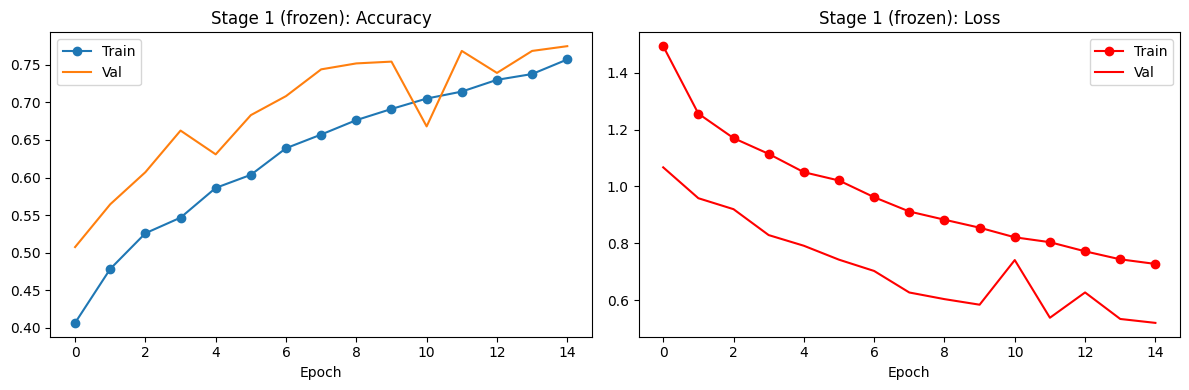

In [7]:

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_stage1.history['accuracy'], 'o-', label='Train')
plt.plot(history_stage1.history['val_accuracy'], '-', label='Val')
plt.title('Stage 1 (frozen): Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_stage1.history['loss'], 'o-', color='red', label='Train')
plt.plot(history_stage1.history['val_loss'], '-', color='red', label='Val')
plt.title('Stage 1 (frozen): Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()


In [23]:
model.save('/kaggle/working/stage1_best_model.h5')

In [14]:
model.save_weights('/kaggle/working/stage1_best.weights.h5')

import os
print(os.path.exists('/kaggle/working/stage1_best.weights.h5'))
print(os.path.getsize('/kaggle/working/stage1_best.weights.h5') / (1024**2), "MB")

True
1400.729148864746 MB


In [9]:
model.save('/kaggle/working/stage1_best_model.keras')

In [10]:
import os

model.save('/kaggle/working/stage1_best_model.keras')

print(os.path.exists('/kaggle/working/stage1_best_model.keras'))
print(os.path.getsize('/kaggle/working/stage1_best_model.keras') / (1024**2), "MB")

True
1400.9111518859863 MB


In [11]:
import os

print(os.listdir('/kaggle/working'))

['.virtual_documents', 'stage1_best_model.keras']


In [12]:
from IPython.display import display, HTML

file_path = '/kaggle/working/stage1_best_model.keras'

display(HTML(
    f'<a href="/kaggle/working/stage1_best_model.keras" download>'
    '👉 Download Stage 1 Model'
    '</a>'
))

In [13]:
import os

print(os.path.exists('/kaggle/working/stage1_best_model.keras'))
print(os.path.getsize('/kaggle/working/stage1_best_model.keras') / (1024**3), "GB")

True
1.3680772967636585 GB


## 7. Stage 2 — MY CONTRIBUTION: fine-tune the last backbone block

Unfreeze `conv5_*` (ResNet50's last residual stage) and `block5_*` (VGG16's last conv block),
then continue training end-to-end at a much lower learning rate. This is the one change that
distinguishes this notebook from the base paper.

In [15]:

n_unfrozen = 0
for layer in model.layers:
    if layer.name.startswith('conv5_') or layer.name.startswith('block5_'):
        layer.trainable = True
        n_unfrozen += 1
print(f'Unfroze {n_unfrozen} layers for fine-tuning.')

model.compile(
    optimizer=Adam(learning_rate=1e-5, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_stage2 = model.fit(
    make_train_gen(),
    validation_data=make_test_gen(),
    epochs=15,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1)
    ],
    verbose=1
)


Unfroze 36 layers for fine-tuning.
Found 5058 validated image filenames.
Found 1265 validated image filenames.
Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 132s 645ms/step - accuracy: 0.7679 - loss: 0.7077 - val_accuracy: 0.7478 - val_loss: 0.6093 - learning_rate: 1.0000e-05
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 83s 518ms/step - accuracy: 0.7883 - loss: 0.6654 - val_accuracy: 0.8071 - val_loss: 0.4514 - learning_rate: 1.0000e-05
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 83s 521ms/step - accuracy: 0.8106 - loss: 0.5869 - val_accuracy: 0.8324 - val_loss: 0.4096 - learning_rate: 1.0000e-05
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 82s 513ms/step - accuracy: 0.8193 - loss: 0.5658 - val_accuracy: 0.8300 - val_loss: 0.4105 - learning_rate: 1.0000e-05
Epoch 5/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 84s 528ms/step - accuracy: 0.8345 - loss: 0.5305 - val_accuracy: 0.8427 - val_loss: 0.3937 - learning_rate: 1.0000e-05
Epoch 6/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 84s 526ms/step - accuracy: 0.8464 - loss: 0.5003 - va

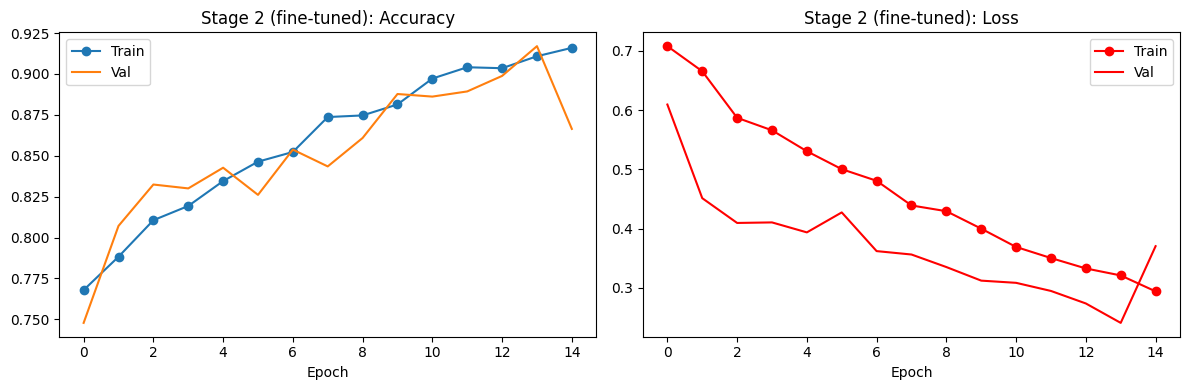

In [16]:

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_stage2.history['accuracy'], 'o-', label='Train')
plt.plot(history_stage2.history['val_accuracy'], '-', label='Val')
plt.title('Stage 2 (fine-tuned): Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_stage2.history['loss'], 'o-', color='red', label='Train')
plt.plot(history_stage2.history['val_loss'], '-', color='red', label='Val')
plt.title('Stage 2 (fine-tuned): Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()


In [19]:
import os

os.makedirs('/kaggle/working/models', exist_ok=True)

model.save('/kaggle/working/models/stage2_best_model.keras')

print("Stage 2 model saved successfully!")
print("Size:",
      os.path.getsize('/kaggle/working/models/stage2_best_model.keras')
      / (1024**3), "GB")

Stage 2 model saved successfully!
Size: 1.5324338153004646 GB


In [20]:
model.save('/kaggle/working/stage2_best_model.h5')

In [21]:
import os
print(os.path.exists('/kaggle/working/stage2_best_model.h5'))

True


## 8. Evaluate the final (fine-tuned) model

Found 1265 validated image filenames.
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 396ms/step
Test Accuracy   : 91.70%
Macro AUC       : 98.81%
Weighted AUC    : 99.15%

              precision    recall  f1-score   support

          F0      1.000     1.000     1.000       423
          F1      0.789     0.872     0.829       172
          F2      0.857     0.755     0.803       159
          F3      0.824     0.877     0.850       171
          F4      0.961     0.932     0.946       340

    accuracy                          0.917      1265
   macro avg      0.886     0.887     0.886      1265
weighted avg      0.919     0.917     0.917      1265



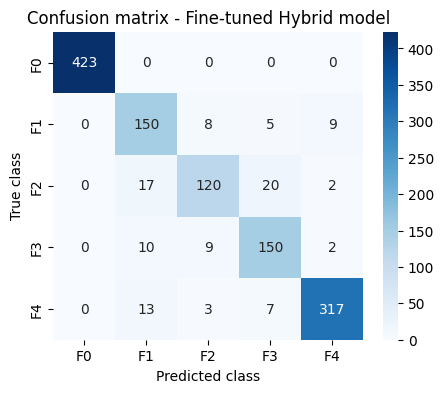

In [17]:

test_gen = make_test_gen()
y_true = test_df['label'].values
y_proba = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_proba, axis=1)

accuracy = (y_true == y_pred).mean()
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
macro_auc = roc_auc_score(y_true_bin, y_proba, average='macro', multi_class='ovr')
weighted_auc = roc_auc_score(y_true_bin, y_proba, average='weighted', multi_class='ovr')

print(f'Test Accuracy   : {accuracy*100:.2f}%')
print(f'Macro AUC       : {macro_auc*100:.2f}%')
print(f'Weighted AUC    : {weighted_auc*100:.2f}%')
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion matrix - Fine-tuned Hybrid model')
plt.xlabel('Predicted class'); plt.ylabel('True class')
plt.show()


## 9. Save the trained model

Saves in the modern Keras format (`.keras`) plus a `.h5` copy for wider compatibility, both to
`/kaggle/working/` so they appear in the notebook's **Output** tab and can be downloaded from
there once the notebook finishes running.

In [18]:

os.makedirs('/kaggle/working/models', exist_ok=True)

model.save('/kaggle/working/models/hybrid_finetuned_liver_fibrosis.keras')
model.save('/kaggle/working/models/hybrid_finetuned_liver_fibrosis.h5')

results_summary = pd.DataFrame([{
    'Model': 'Hybrid ResNet50-VGG16 (fine-tuned, my contribution)',
    'Accuracy (%)': round(accuracy * 100, 2),
    'Macro AUC (%)': round(macro_auc * 100, 2),
    'Weighted AUC (%)': round(weighted_auc * 100, 2),
}])
results_summary.to_csv('/kaggle/working/models/results_summary.csv', index=False)

print('Saved:')
print(' - /kaggle/working/models/hybrid_finetuned_liver_fibrosis.keras')
print(' - /kaggle/working/models/hybrid_finetuned_liver_fibrosis.h5')
print(' - /kaggle/working/models/results_summary.csv')
print()
print('Download from the notebook\'s "Output" / "Data" tab after this cell finishes running.')
results_summary


Saved:
 - /kaggle/working/models/hybrid_finetuned_liver_fibrosis.keras
 - /kaggle/working/models/hybrid_finetuned_liver_fibrosis.h5
 - /kaggle/working/models/results_summary.csv

Download from the notebook's "Output" / "Data" tab after this cell finishes running.


,Model,Accuracy (%),Macro AUC (%),Weighted AUC (%)
0,"Hybrid ResNet50-VGG16 (fine-tuned, my contribu...",91.7,98.81,99.15


Predicted Stage : F3
Confidence      : 72.75%


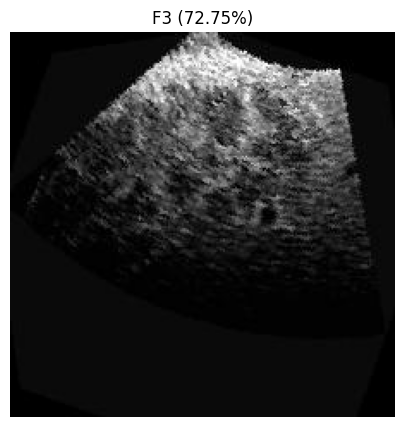

In [22]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = 224
CLASS_NAMES = ['F0', 'F1', 'F2', 'F3', 'F4']

# Load your final trained model
model = load_model('/kaggle/working/models/hybrid_finetuned_liver_fibrosis.keras')

# Same preprocessing used during training
def preprocess(img):
    img_uint8 = np.clip(img, 0, 255).astype('uint8')
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray_eq = cv2.equalizeHist(gray)
    rgb_eq = cv2.cvtColor(gray_eq, cv2.COLOR_GRAY2RGB)
    return rgb_eq.astype('float32') / 255.0

def predict_image(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img)

    img = preprocess(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)

    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class] * 100

    print("Predicted Stage :", CLASS_NAMES[predicted_class])
    print("Confidence      :", f"{confidence:.2f}%")

    plt.figure(figsize=(5, 5))
    plt.imshow(load_img(image_path))
    plt.title(f"{CLASS_NAMES[predicted_class]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

predict_image('/kaggle/input/datasets/evelinj/test-data/liver_fibrosis_test_image.jpg')

In [27]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

IMG_SIZE = 224
CLASS_NAMES = ['F0', 'F1', 'F2', 'F3', 'F4']

# Load final Stage 2 model
MODEL_PATH = '/kaggle/working/stage2_best_model.h5'
model = load_model(MODEL_PATH)

# Same preprocessing used during training
def preprocess(img):
    img_uint8 = np.clip(img, 0, 255).astype('uint8')

    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray_eq = cv2.equalizeHist(gray)
    rgb_eq = cv2.cvtColor(gray_eq, cv2.COLOR_GRAY2RGB)

    return rgb_eq.astype('float32') / 255.0


def predict_image(image_path):

    img = load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img = img_to_array(img)
    img = preprocess(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)[0]

    predicted_class = np.argmax(prediction)
    confidence = prediction[predicted_class] * 100

    return CLASS_NAMES[predicted_class], confidence


# Correct test folder
TEST_FOLDER = '/kaggle/input/datasets/evelinj/checking-test'

image_files = sorted([
    f for f in os.listdir(TEST_FOLDER)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

print("\n" + "=" * 60)
print("LIVER FIBROSIS PREDICTIONS")
print("=" * 60)

for image_file in image_files:

    image_path = os.path.join(TEST_FOLDER, image_file)

    predicted_stage, confidence = predict_image(image_path)

    print(
        f"{image_file:<30} → "
        f"{predicted_stage} ({confidence:.2f}%)"
    )

print("=" * 60)
print(f"Total images tested: {len(image_files)}")
print("=" * 60)


LIVER FIBROSIS PREDICTIONS
liver_fibrosis.jpg             → F0 (100.00%)
liver_fibrosis_1.jpg           → F1 (81.31%)
liver_fibrosis_2.jpg           → F2 (69.14%)
liver_fibrosis_3.jpg           → F3 (69.08%)
liver_fibrosis_4.jpg           → F3 (90.19%)
Total images tested: 5


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/evelinj/testing_f4'

## 10. For your paper

**Contribution statement (fill in your actual numbers from Section 8 above):**
> Unlike the base paper, which keeps ResNet50 and VGG16 fully frozen throughout training, we
> introduce a two-stage progressive fine-tuning strategy: the classification head is first
> trained with frozen backbones (Stage 1), after which the last convolutional block of each
> backbone is unfrozen and fine-tuned at a reduced learning rate (Stage 2). This adapts the
> ImageNet-pretrained filters to ultrasound-specific texture and achieved **X% accuracy /
> Y% macro AUC** on the held-out test set, compared to **A% / B%** with frozen backbones alone.

**What to report:** the Stage 1 vs. Stage 2 accuracy/AUC from the training logs above, the
final classification report and confusion matrix (Section 8), and the saved model as your
trained artifact.

**Limitation to state honestly (unchanged from the base paper):** evaluation is at the image
level, not the patient level, since only image-level labels are available in the public dataset.
